In [1]:
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

basepath = './datasets/ufpe/'
yearpath = basepath + ''
path = yearpath + 'cross-validation/'
backtestpath = path + 'backtests/'
forecastpath = path + 'forecasts/'

collen = 10

In [2]:
# prompt: load all saved backtests from folder into backtests list
import os

def load_backtests(path):
  # Assuming 'backtests' is the directory containing the CSV files
  backtest_dir = os.path.join(path)
  backtests = []
  titles = []
  i = 0

  # Iterate through the files in the directory
  for filename in os.listdir(backtest_dir):
    if filename.endswith(".csv"):
      filepath = os.path.join(backtest_dir, filename)
      try:
        # Read the CSV file into a Pandas DataFrame
        df = pd.read_csv(filepath)
        title = filename.removesuffix('.csv').replace('_NEG', '_INV')

        # Append _INV to column names if the filename ends with _NEG/_INV
        if title.endswith('_INV'):
            inv_cols = {col: f"{col}_INV" for col in df.columns if col != 'Datetime'}
            df = df.rename(columns=inv_cols)

        backtests.append(df)
        titles.append(title)
        print(f"Backtest loaded[{i}]: {title} ({filename})")
        i += 1
      except pd.errors.EmptyDataError:
        print(f"Warning: Skipping empty file: {filename}")
      except pd.errors.ParserError:
        print(f"Warning: Skipping file with parsing error: {filename}")

  return backtests, titles

In [3]:
# loading backtests
backtests, titles = load_backtests(backtestpath)

Backtest loaded[0]: tide (tide.csv)
Backtest loaded[1]: mlp (mlp.csv)
Backtest loaded[2]: dlinear (dlinear.csv)
Backtest loaded[3]: patch_tst (patch_tst.csv)
Backtest loaded[4]: B&H (B&H.csv)
Backtest loaded[5]: autoformer (autoformer.csv)
Backtest loaded[6]: rnn (rnn.csv)
Backtest loaded[7]: tft (tft.csv)
Backtest loaded[8]: dumb_4cast (dumb_4cast.csv)
Backtest loaded[9]: dilated_rnn (dilated_rnn.csv)
Backtest loaded[10]: tcn (tcn.csv)
Backtest loaded[11]: nhits (nhits.csv)
Backtest loaded[12]: nlinear (nlinear.csv)
Backtest loaded[13]: rmok (rmok.csv)
Backtest loaded[14]: itransformer (itransformer.csv)
Backtest loaded[15]: ts_mixerx (ts_mixerx.csv)
Backtest loaded[16]: stemgnn (stemgnn.csv)
Backtest loaded[17]: informer (informer.csv)
Backtest loaded[18]: gru (gru.csv)
Backtest loaded[19]: ts_mixer (ts_mixer.csv)
Backtest loaded[20]: deep_ar (deep_ar.csv)
Backtest loaded[21]: bitcn (bitcn.csv)
Backtest loaded[22]: mlpmulti (mlpmulti.csv)
Backtest loaded[23]: deep_npts (deep_npts.csv

In [4]:
# Merge all backtest dataframes into one
date_column_name = "Datetime"

merged_backtests_df = pd.DataFrame()

for i, df in enumerate(backtests):
    # Prefix column names with the backtest title, excluding the date column
    prefixed_cols = {col: f"{titles[i].replace('_INV', '')}-{col}" for col in df.columns if col != date_column_name}
    temp_df = df.rename(columns=prefixed_cols)

    if merged_backtests_df.empty:
        merged_backtests_df = temp_df
    else:
        # Merge on the date column
        merged_backtests_df = pd.merge(merged_backtests_df, temp_df, on=date_column_name, how='outer')

merged_backtests_df.set_index(date_column_name, inplace=True)

# Display the merged dataframe
print("Merged Backtest Dataframe:")
display(merged_backtests_df.iloc[:,:collen])

Merged Backtest Dataframe:


,tide-ATOM,tide-AVAX,tide-AXS,tide-BAND,tide-BAT,tide-BCH,tide-BNB,tide-BTC,tide-CAKE,tide-CELO
Datetime,,,,,,,,,,
2025-06-02 01:00:00,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2025-06-02 02:00:00,99.584392,99.518304,99.214454,99.235474,99.456522,100.274383,99.781980,99.656879,99.490662,98.659354
2025-06-02 03:00:00,99.399677,99.084778,98.743126,98.776758,99.534161,100.676183,99.423156,99.469278,99.278438,98.171846
2025-06-02 04:00:00,99.561565,99.036632,98.468185,98.623853,99.611862,100.324432,99.566988,99.408750,99.023769,98.202316
2025-06-02 05:00:00,99.723982,98.940480,98.350494,98.167261,99.379124,99.776620,99.629102,99.343975,99.108732,98.171856
...,...,...,...,...,...,...,...,...,...,...
2025-12-10 21:00:00,47.891066,33.550054,37.964498,73.866670,26.490369,69.343071,180.460698,139.277916,83.177098,58.920596
2025-12-10 22:00:00,48.185521,33.503065,38.068700,73.473762,26.296488,69.475612,180.734324,139.509492,83.426772,59.130652
2025-12-10 23:00:00,47.680741,33.150649,37.790827,72.884400,26.051584,68.993644,179.754500,138.763657,83.965241,58.780559


In [5]:
# Calculate the percentage change row to row
pct_change_merged_backtests_df = merged_backtests_df.pct_change()

# Display the resulting DataFrame
print("Percentage change row to row:")
display(pct_change_merged_backtests_df.iloc[:,:collen])

Percentage change row to row:


,tide-ATOM,tide-AVAX,tide-AXS,tide-BAND,tide-BAT,tide-BCH,tide-BNB,tide-BTC,tide-CAKE,tide-CELO
Datetime,,,,,,,,,,
2025-06-02 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-02 02:00:00,-0.004156,-0.004817,-0.007855,-0.007645,-0.005435,0.002744,-0.002180,-0.003431,-0.005093,-0.013406
2025-06-02 03:00:00,-0.001855,-0.004356,-0.004751,-0.004622,0.000781,0.004007,-0.003596,-0.001882,-0.002133,-0.004941
2025-06-02 04:00:00,0.001629,-0.000486,-0.002784,-0.001548,0.000781,-0.003494,0.001447,-0.000609,-0.002565,0.000310
2025-06-02 05:00:00,0.001631,-0.000971,-0.001195,-0.004630,-0.002336,-0.005460,0.000624,-0.000652,0.000858,-0.000310
...,...,...,...,...,...,...,...,...,...,...
2025-12-10 21:00:00,-0.015564,-0.009709,-0.011754,-0.010526,-0.018896,0.000521,-0.002114,-0.001055,-0.005544,-0.016939
2025-12-10 22:00:00,0.006148,-0.001401,0.002745,-0.005319,-0.007319,0.001911,0.001516,0.001663,0.003002,0.003565
2025-12-10 23:00:00,-0.010476,-0.010519,-0.007299,-0.008021,-0.009313,-0.006937,-0.005421,-0.005346,0.006454,-0.005921


###Commonly Used n Values (Lookback Periods)

| Use Case                | Typical `n` Values | Timeframe          | Comment                                              |
| ----------------------- | ------------------ | ------------------ | ---------------------------------------------------- |
| **Intraday (HFT)**      | 3, 5, 10, 20       | 1-min to 15-min    | Short-term noise, fast reversals                     |
| **Swing Trading**       | 5, 10, 14, 21      | 1-hour to 1-day    | Popular with technical indicators                    |
| **Medium-Term**         | 20, 50             | 1-day or 4-hour    | Monthly momentum strategies                          |
| **Long-Term Investing** | 90, 180, 252       | 1-day (daily bars) | Institutional quant strategies often use 6–12 months |

###Empirical studies and real-world quant funds (e.g., AQR) show:
* 3 to 12-month price momentum has predictive power for equities and crypto.
* For hourly crypto trading, lookbacks of 10 to 50 bars (i.e., 10–50 hours) are commonly backtested.
* Shorter n (like 3–5) is good for scalping/microtrends, but has more noise.
* Longer n (like 50+) smooths noise but lags more.

###Suggestion for Starting Values
* For hourly crypto trading: try n = 10, 20, 50
* For daily swing trading: try n = 14, 21, 50, 100
* For minute data strategies: start with n = 3, 5, 9

(source: https://chatgpt.com/share/689f8e7c-8804-8003-947a-539212d19d58)

### Wallet realocation:
1. fully sell assets in wallet not in selected_df
2. partially sell assets in wallet with higher share than selected_df (if difference higher than spread + taxes)
3. add profit to balance
4. proportionally allocate balance for each asset
5. fully buy assets not in wallet
6. partially buy assets in wallet with lower share than selected_df (if prediction is higher than spread + taxes)

---

How to trust the predictive capacity of the model-asset?
* if it's guessing right (backtest momentum analysis with different n's) then the prediction is reliable
* the ones with higher % momentum scores are the most reliable x performant ones

Algorithm:
```
    * n_list <- momentum loopbacks (how many rows back the current one will be compared. -1 is the 1st)
    * WSIZE <- wallet's max number of assets
    * MIN_THRESH <- min threshold (1.01 month, 1.0003317327062 day, 1.0000138199995 hour)
    * MIN_ALLOC <- min % difference to consider
    * merged_backtests_df <- merge all model-assets backtests in only one dataframe

    for all n's:
        calculate % momentum between last and (last - n) rows
        select WSIZE best assets

    wallet <- {}
    balance <- INITIAL_BALANCE

    for i from max(n_list) to len(merged_backtests_df)
        momentum <- calculate momentum subdataframe fom n_list
        new_wallet <- select WSIZE assets with higher momentum score
        
        filter (remove) assets from wallet and new_wallet with score lower than MIN_THRESH
        
        realize profit selling assets in wallet not in new wallet (or with lower share)
        
        balance <- balance + toSell
        
        reallocate balance on new wallet proportionally to momentum
            strategies (exclusive):
                A. divide equally X proportional to their score (up to a limit)
                B. one budget for all X one budget for each n

        adjust wallet
            add new assets to wallet
            increase budget to assets in wallet (if higher than MIN_ALLOC)
        
```

In [6]:
WALLET_LEN = 10
AVG_BALANCE_BY_ASSET = 100
TOTAL_BALANCE = AVG_BALANCE_BY_ASSET * WALLET_LEN

WSIZE = WALLET_LEN # Wallet's max number of assets
MIN_THRESH = 1.0000138199995 # min threshold (1% monthly, for hourly data)
MIN_ALLOC = 0.05 # min % difference to consider (5%)

### complete algorithm

2ª tentativa do algoritmo de gestão da carteira.

Nessa abordagem vamos seguir com uma estratégia mais simples para tentar aproximar do desempenho dos 10 melhores ativos-modelos:
1. Atualiza carteira (conforme rendimento real)
1. Calcula nova carteira
    1. Calcula o momento comparando linhas específicas (ex: 3 linhas antes da atual, 5, 10, 100...) e multiplica os momentos
    1. Seleciona os N maiores momentos para a nova carteira
    1. Filtrar ativos da nova carteira
        - Rendimento total precisa ser superior a um valor mínimo (ex: 1% ao mês ajustado para o passo)
        - Ativos em situação de LOSS (rendimento a curto prazo abaixo da tolerância)
1. Ajusta carteira
    1. Vende ativos da carteira que não estão na nova carteira e joga em conta (balance)
    1. STOP-LOSS: vende ativos cujo rendimento a curto prazo estão abaixo da tolerância
    1. Divide o valor em conta igualmente para os ativos que serão adquiridos
    1. Adquire ativos da nova carteira que não estão na carteira

In [7]:
import math

def min_interest(min_interest_month, n_list):
    ''' MIN_THRESH adjusted for n_list (each value is 1% per month, so must multiply
    everyone bcs the interest gets acumulated) '''
    min_interest_hour = math.pow(min_interest_month, 1/(24*30))
    min_interest_n = 1.0

    for i in range(len(n_list)):
        min_interest_n *= min_interest_hour ** abs(n_list[i])

    return min_interest_n

# MIN_INTEREST_MONTH = 1.01 # 1% per month
# n_list = [-609, -377, -3, -1]

# min_interest(MIN_INTEREST_MONTH, n_list)

In [8]:
def update_wallet(wallet, pct_change_row):
    ''' Update wallet based on percentage change of selected assets'''

    for asset in wallet.keys():
        # Get the percentage change for the current asset from the latest row
        # Add 1 to get the multiplication factor for the current price
        change_factor = pct_change_row[asset] + 1
        # Update the asset value in the wallet
        wallet[asset] *= change_factor

    return

In [9]:
def adjust_wallet(wallet, balance, new_wallet_momentum, verbose):
    ''' Adjust wallet selling assets with low momentum end buying ones with higher. '''
    # ----- 3. Ajusta carteira
    # ----- 3.1 Vende ativos da carteira que não estão na nova carteira e joga em conta (balance)
    # ----- 3.2 STOP-LOSS: vende ativos cujo rendimento a curto prazo estão abaixo da tolerância
    # ----- 3.3 Divide o valor em conta igualmente para os ativos que serão adquiridos
    # ----- 3.4 Adquire ativos da nova carteira que não estão na carteira

    # Reallocate balance on new wallet proportionally to momentum
    # total_new_momentum = filtered_new_wallet_candidates.sum(axis=1)
    # Calculate the sum of the 'Momentum' row in the selected_df
    total_momentum = new_wallet_momentum.sum()

    # Calculate the proportion of momentum for each selected asset
    momentum_proportions = new_wallet_momentum / total_momentum

    # Calculate the balance to be allocated to each asset
    new_wallet = (momentum_proportions * balance).to_dict()

    # Adjust wallet based on new_wallet and MIN_ALLOC
    assets_to_sell = [asset for asset in wallet if asset not in new_wallet]
    #print(f"Selling assets. Current balance = ${balance:.2f}")
    for asset in assets_to_sell:
        balance += wallet[asset]  # Sell asset and add value to balance
        #print(f"Selling {asset} ${wallet[asset]:.2f}, balance = ${balance:.2f}")
        del wallet[asset]

    assets_to_buy = [asset for asset in new_wallet if asset not in wallet]
    #print(f"Buying assets. Current balance = ${balance:.2f}")
    for asset in assets_to_buy:
        # Allocate based on the calculated proportional balance for new assets
        allocation = new_wallet[asset]
        if balance + .01 >= allocation:
            wallet[asset] = allocation  # Buy asset and subtract value from balance
            balance -= allocation
            #print(f"Buying {asset} ${wallet[asset]:.2f}, balance = ${balance:.2f}")
        else:
            if verbose:
                print(f"Warning: Insufficient balance to buy {asset}. Needed: ${allocation:.2f}, Available: ${balance:.2f}")
                #raise ValueError(f"Insufficient balance to buy {asset}. Needed: ${allocation:.2f}, Available: ${balance:.2f}")

    assets_in_both = [asset for asset in wallet if asset in new_wallet]
    #print(f"Adjusting current assets. Current balance = ${balance:.2f}")
    for asset in assets_in_both:
        current_allocation = wallet[asset]
        new_allocation = new_wallet[asset]
        difference = new_allocation - current_allocation

        if (current_allocation) > 0 and (abs(difference) / current_allocation > MIN_ALLOC):
            if difference > 0:  # Need to buy more
                if balance + .01 >= difference:
                    wallet[asset] = new_allocation
                    balance -= difference
                    #print(f"Buying {asset} ${difference:.2f} more, current ${new_allocation:.2f}, balance = ${balance:.2f}")
                else:
                    if verbose:
                        print(f"Warning: Insufficient balance to increase allocation for {asset}. Needed: ${difference:.2f}, Available: ${balance:.2f}")
                        #raise ValueError(f"Warning: Insufficient balance to increase allocation for {asset}. Needed: ${difference:.2f}, Available: ${balance:.2f}")
            else:  # Need to sell some
                wallet[asset] = new_allocation
                balance += abs(difference)
                #print(f"Selling {asset} ${difference:.2f}, current ${new_allocation:.2f}, balance = ${balance:.2f}")

    return wallet, balance

In [10]:
def adjust_wallet_simple(wallet, balance, new_wallet_momentum, verbose):
    ''' Adjust wallet selling assets with low momentum end buying ones with higher. '''
    # ----- 3. Ajusta carteira
    # ----- 3.1 Vende ativos da carteira que não estão na nova carteira e joga em conta (balance)
    # ----- 3.2 STOP-LOSS: vende ativos cujo rendimento a curto prazo estão abaixo da tolerância
    # ----- 3.3 Divide o valor em conta igualmente para os ativos que serão adquiridos
    # ----- 3.4 Adquire ativos da nova carteira que não estão na carteira

    new_wallet = new_wallet_momentum.to_dict()

    # Adjust wallet based on new_wallet and MIN_ALLOC
    assets_to_sell = [asset for asset in wallet if asset not in new_wallet]
    #print(f"Selling assets. Current balance = ${balance:.2f}")
    for asset in assets_to_sell:
        balance += wallet[asset]  # Sell asset and add value to balance
        #print(f"Selling {asset} ${wallet[asset]:.2f}, balance = ${balance:.2f}")
        del wallet[asset]

    assets_to_buy = [asset for asset in new_wallet if asset not in wallet]
    if len(assets_to_buy) > 0:
        balance_for_each_asset = balance / len(assets_to_buy)
    #print(f"Buying assets. Current balance = ${balance:.2f}")
    for asset in assets_to_buy:
        wallet[asset] = balance_for_each_asset  # Buy asset and subtract value from balance
        balance -= balance_for_each_asset

    return wallet, balance

In [11]:
def manage_wallet_simple(full_df, percent_full_df, n_list, wallet_len, initial_balance, verbose = False, min_start = -1):

    # min interest according to informed momentum
    MIN_INTEREST_MONTH = 1.01 # 1% per month
    MIN_INTEREST_N = min_interest(MIN_INTEREST_MONTH, n_list)

    # if lowest value of n_list is -N, start at row N
    start = max([abs(n) for n in n_list])
    # max_n = max(n_list)
    # min_n = min(n_list)
    # if (max_n < 0):
    #     start = abs(min_n)
    # else:
    #     start = max_n + 1

    # or start at specified value from parameter
    if start < min_start:
        start = min_start

    # analyse until end of dataframe
    end = len(percent_full_df)

    # Initialize wallet and balance
    wallet = {}
    balance = initial_balance

    # monitor wallet evolution
    history_balance = []
    history_date = []

    steps = 0 # aux var to print progress dots

    # Iterate through the merged backtests dataframe starting from the max lookback period
    for i in range(start, end):

        # ----- 1. Atualiza carteira (conforme rendimento real)

        # How much each of the assets in wallet appreciated or depreciated on last real step
        # BE CAREFULL! IF PICKED ONLY ONE LINE THE INDEX MUST BE i-1!!!
        update_wallet(wallet, percent_full_df.iloc[i-1])

        # ----- 2. Calcula nova carteira
        new_wallet_momentum = new_wallet(full_df, i, n_list, MIN_INTEREST_N, wallet_len)

        # ----- 3. Ajusta carteira
        wallet, balance = adjust_wallet_simple(wallet, balance, new_wallet_momentum, verbose)

        # Sum all elements of wallet and print it in currency format
        total_wallet_value = sum(wallet.values())

        history_date.append(merged_backtests_df.index[i])
        history_balance.append((balance + total_wallet_value))

        steps += 1
        if verbose:
            if steps % 100 == 0:
                print('.', end='')
            if steps % 1000 == 0:
                print(steps, end='')

    if verbose:
        if steps% 1000 != 0:
            print('', steps)
        else:
            print('')
            # display(new_wallet_momentum.to_frame().T)

    return history_date, history_balance, (balance + total_wallet_value), wallet, steps

# n_list = [-609, -377, -3, -1]
# wallet_len = 7
# history_date, history_balance, total_ballance, wallet, steps = manage_wallet_simple(merged_backtests_df, pct_change_merged_backtests_df, n_list, wallet_len, TOTAL_BALANCE, True)
# print(f'\n${total_ballance:.2f}')

In [12]:
# print('¯\_(ツ)_/¯')

def new_wallet(full_df, i, n_list, min_interest, wallet_len):
    ''' Calculate new wallet '''
    # ----- 2. Calcula nova carteira
    # ----- 2.1 Calcula o momento comparando linhas específicas (ex: 3 linhas antes da atual, 5, 10, 100...) e multiplica os momentos

    # Get subframe to simulate row i is the current one
    merged_backtests_subframe = full_df.iloc[:i]

    # Calculate momentum subdataframe for the current time step based on n_list
    sub_merged_backtests_df = merged_backtests_subframe.iloc[n_list]

    # Calculate the percentage change compared to the last row
    # Get the last row as a Series
    last_row = sub_merged_backtests_df.iloc[-1]
    # Calculate the percentage change of each row compared to the last row
    pct_change_compared_to_last = ((last_row - sub_merged_backtests_df) / last_row) + 1

    # For each column individually, calculate the product of all row values
    product_row = pct_change_compared_to_last.prod(axis=0)

    # ----- 2.2 Seleciona os N maiores momentos para a nova carteira

    # Sort the product_row in descending order
    sorted_product_row = product_row.sort_values(ascending=False)

    # Select WSIZE best assets based on momentum score
    # sorted_momentum = momentum_row.sort_values(ascending=False)
    new_wallet_candidates = sorted_product_row[:wallet_len]

    # ----- 2.3 Filtrar ativos da nova carteira
    # -----      . Rendimento total precisa ser superior a um valor mínimo (ex: 1% ao mês ajustado para o passo)
    # -----      . Ativos em situação de LOSS (rendimento a curto prazo abaixo da tolerância)

    # Filter (remove) assets with score higher than MIN_THRESH
    new_wallet_momentum = new_wallet_candidates[new_wallet_candidates > min_interest]

    return new_wallet_momentum

In [13]:
import matplotlib.pyplot as plt

def plot_balance_over_time(history_date, history_balance):
    # Create a pandas Series for plotting
    balance_series = pd.Series(history_balance, index=history_date)

    # Plot the balance over time
    plt.figure(figsize=(20, 6))
    balance_series.plot()
    plt.title('Historical Total Balance Over Time')
    plt.xlabel('Date')
    plt.ylabel('Balance ($)')
    plt.grid(True)
    plt.show()

In [14]:
import plotly.graph_objects as go

def plot_balance_over_time_plotly(history_date, history_balance, wallet_len = 0, total_ballance = 0, monthly_interest = 0, n_list = []):
    if wallet_len > 0:
        title = f'Historical Total Balance Over Time: wallet len = {wallet_len}, n_list = {n_list}, final balance: ${total_ballance:.2f}, {monthly_interest:.1f}% pm'
    else:
        title = 'Historical Total Balance Over Time'

    # Create a pandas Series for plotting
    balance_series = pd.Series(history_balance, index=history_date)

    # Create a Plotly figure
    fig = go.Figure()

    # Add the balance trace
    fig.add_trace(go.Scatter(x=balance_series.index, y=balance_series.values, mode='lines', name='Total Balance'))

    # Update layout for better appearance
    fig.update_layout(
        title=title,
        xaxis_title='Date',
        yaxis_title='Balance ($)',
        xaxis_tickformat='%Y-%m-%d %H:%M:%S',
        hovermode='x unified'
    )

    # Display the plot
    fig.show()

In [15]:
import math

def calculate_monthly_interest_rate(pv: float, fv: float, n_hours: int) -> float:
    hourly_interest = math.pow(fv / pv, 1/n_hours)
    monthly_interest = math.pow(hourly_interest, 24 * 30)
    return (monthly_interest - 1) * 100

#calculate_monthly_interest_rate(TOTAL_BALANCE, total_ballance, steps)
#print(f"PV = ${TOTAL_BALANCE:.2f}, FV = ${total_ballance:.2f}, {steps} hours, Avg monthly return: {calculate_monthly_interest_rate(TOTAL_BALANCE, total_ballance, steps):.2f}%")

In [16]:
# Momentum lookbacks
# n_list = [-48, -24, -12, -6, -3, -1] # Wallet len = 10, final balance: $2787.85, 17.6% pm
# n_list = [-48, -24, -12, -1] # Wallet len = 1, final balance: $3153.05, 19.9% pm
# n_list = [-90, -60, -30, -1] # Wallet len = 9, final balance: $8131.47, 39.6% pm
# n_list = [-30*24, -7*24, -24, -1] # plot_balance_over_time_plotly(max_hd, max_hb, max_wl, max_tb, max_mi, n_list)
# n_list = [-24*15, -1] # Wallet len = 10, final balance: $4338.38, 28.2% pm
# n_list = [-533, -300, -9, -3, -1] # Wallet len = 2, final balance: $5463.44, 35.0% pm
# n_list = [-686, -512, -256, -9, -3, -1] # Wallet len = 4, final balance: $11428.19, 56.4% pm
# n_list = [-609, -377, -3, -1] # Wallet len = 7, final balance: $14258.85, 61.3% pm
# n_list = [0, -1] # Wallet len = 5, final balance: $21007.72, 60.9% pm

def plot_momentum(merged_backtests_df, pct_change_merged_backtests_df, n_list, verbose = False):
    start = 30*24*0

    max_tb = 0
    max_wl = 0
    max_mi = 0
    max_hd = []
    max_hb = []

    for wallet_len in range(1, 11):
        history_date, history_balance, total_ballance, wallet, steps = manage_wallet_simple(merged_backtests_df[start:], pct_change_merged_backtests_df[start:], n_list, wallet_len, TOTAL_BALANCE, True)
        if (total_ballance > max_tb):
            max_tb = total_ballance
            max_wl = wallet_len
            max_mi = calculate_monthly_interest_rate(TOTAL_BALANCE, total_ballance, steps)
            max_hd = history_date
            max_hb = history_balance
        if verbose:
            print(f"Wallet len = {wallet_len}, final balance: ${total_ballance:.2f}, {calculate_monthly_interest_rate(TOTAL_BALANCE, total_ballance, steps):.1f}% pm")

    print()
    print(f"Wallet len = {max_wl}, final balance: ${max_tb:.2f}, {max_mi:.1f}% pm")

    plot_balance_over_time_plotly(max_hd, max_hb, max_wl, max_tb, max_mi, n_list)
#plot_balance_over_time_plotly(max_hd, max_hb, max_wl, max_tb, max_mi, n_list)

# wallet_len = 7

# history_date, history_balance, total_ballance, wallet, steps = manage_wallet_simple(merged_backtests_df, pct_change_merged_backtests_df, n_list, wallet_len, TOTAL_BALANCE, True)
# print(f"\nWallet len = {wallet_len}, final balance: ${total_ballance:.2f}, {calculate_monthly_interest_rate(TOTAL_BALANCE, total_ballance, steps):.1f}% pm")

# Final wallet and balance after the loop
# print()

# print(f"Initial Balance: ${TOTAL_BALANCE:.2f}")
# print(f"Period: {steps/24:.0f} days ({steps/(24*30):.1f} months)")
# print(f"Avg monthly return: {calculate_monthly_interest_rate(TOTAL_BALANCE, total_ballance, steps):.1f}%")
# print(f"Final Total Balance: ${total_ballance:.2f}, {calculate_monthly_interest_rate(TOTAL_BALANCE, total_ballance, steps):.1f}% pm")
# print("Final Wallet Allocation:")
# for asset, value in wallet.items():
#     print(f"\t{asset}: ${value:.2f}")

..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561

Wallet len = 4, final balance: $2036.95, 11.9% pm


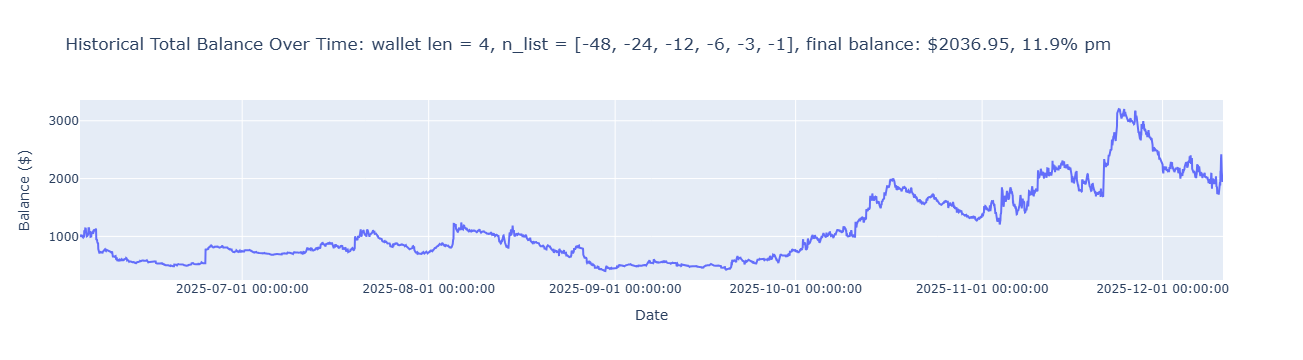

In [17]:
n_list = [-48, -24, -12, -6, -3, -1]
plot_momentum(merged_backtests_df, pct_change_merged_backtests_df, n_list)

..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561
..........1000..........2000..........3000..........4000..... 4561

Wallet len = 5, final balance: $5408.00, 30.5% pm


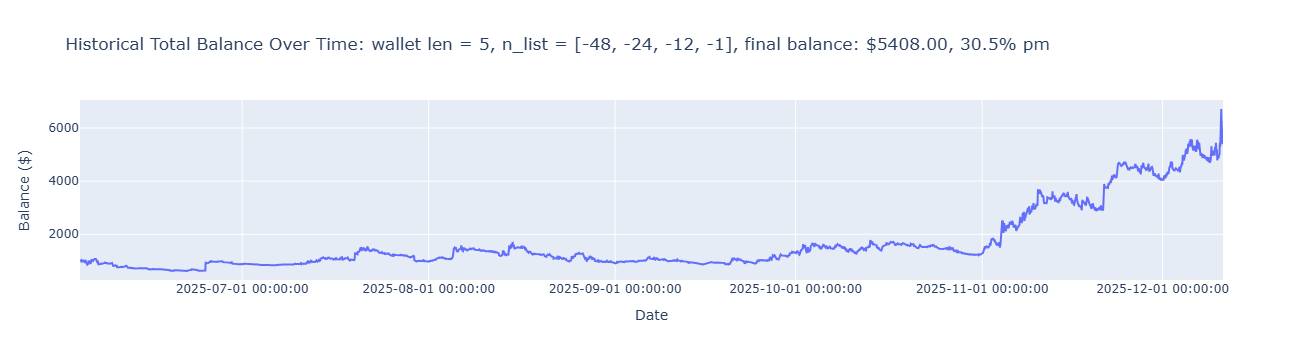

In [18]:
n_list = [-48, -24, -12, -1]
plot_momentum(merged_backtests_df, pct_change_merged_backtests_df, n_list)

..........1000..........2000..........3000..........4000..... 4519
..........1000..........2000..........3000..........4000..... 4519
..........1000..........2000..........3000..........4000..... 4519
..........1000..........2000..........3000..........4000..... 4519
..........1000..........2000..........3000..........4000..... 4519
..........1000..........2000..........3000..........4000..... 4519
..........1000..........2000..........3000..........4000..... 4519
..........1000..........2000..........3000..........4000..... 4519
..........1000..........2000..........3000..........4000..... 4519
..........1000..........2000..........3000..........4000..... 4519

Wallet len = 10, final balance: $3688.84, 23.1% pm


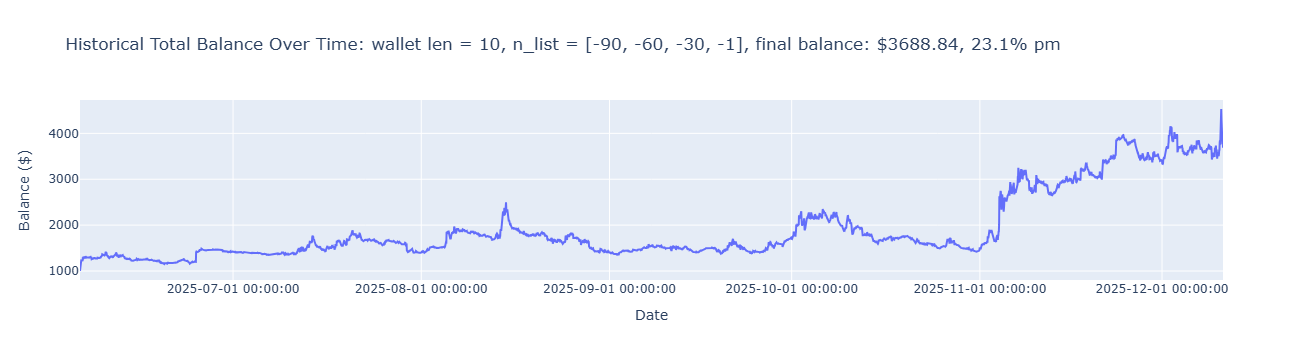

In [19]:
n_list = [-90, -60, -30, -1]
plot_momentum(merged_backtests_df, pct_change_merged_backtests_df, n_list)

..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889

Wallet len = 5, final balance: $4057.63, 29.6% pm


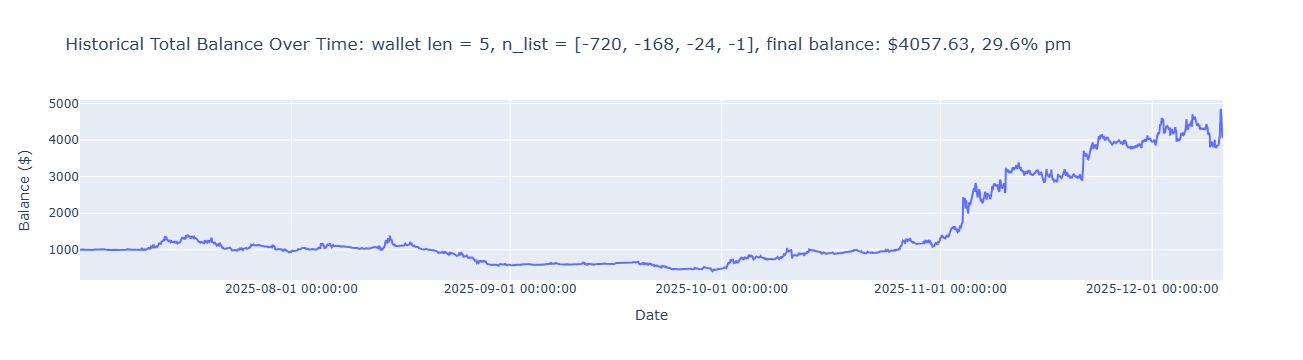

In [20]:
n_list = [-30*24, -7*24, -24, -1]
plot_momentum(merged_backtests_df, pct_change_merged_backtests_df, n_list)

..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889
..........1000..........2000..........3000........ 3889

Wallet len = 5, final balance: $4057.63, 29.6% pm


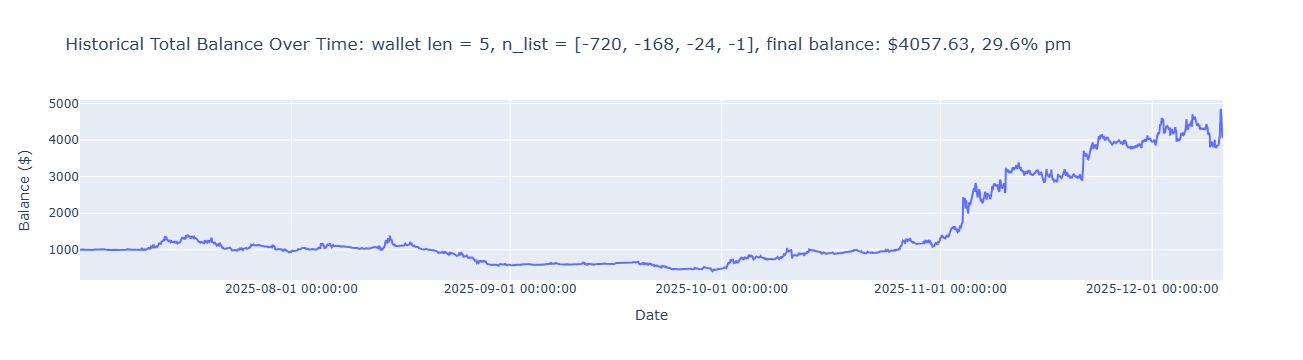

In [21]:
n_list = [-30*24, -7*24, -24, -1]
plot_momentum(merged_backtests_df, pct_change_merged_backtests_df, n_list)

..........1000..........2000..........3000..........4000.. 4249
..........1000..........2000..........3000..........4000.. 4249
..........1000..........2000..........3000..........4000.. 4249
..........1000..........2000..........3000..........4000.. 4249
..........1000..........2000..........3000..........4000.. 4249
..........1000..........2000..........3000..........4000.. 4249
..........1000..........2000..........3000..........4000.. 4249
..........1000..........2000..........3000..........4000.. 4249
..........1000..........2000..........3000..........4000.. 4249
..........1000..........2000..........3000..........4000.. 4249

Wallet len = 4, final balance: $2206.17, 14.3% pm


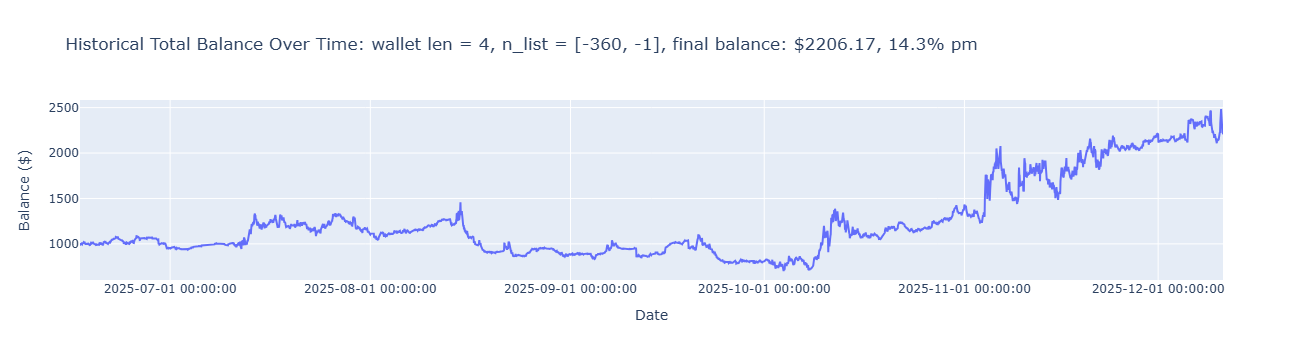

In [22]:
n_list = [-24*15, -1]
plot_momentum(merged_backtests_df, pct_change_merged_backtests_df, n_list)

..........1000..........2000..........3000..........4000 4076
..........1000..........2000..........3000..........4000 4076
..........1000..........2000..........3000..........4000 4076
..........1000..........2000..........3000..........4000 4076
..........1000..........2000..........3000..........4000 4076
..........1000..........2000..........3000..........4000 4076
..........1000..........2000..........3000..........4000 4076
..........1000..........2000..........3000..........4000 4076
..........1000..........2000..........3000..........4000 4076
..........1000..........2000..........3000..........4000 4076

Wallet len = 2, final balance: $3169.46, 22.6% pm


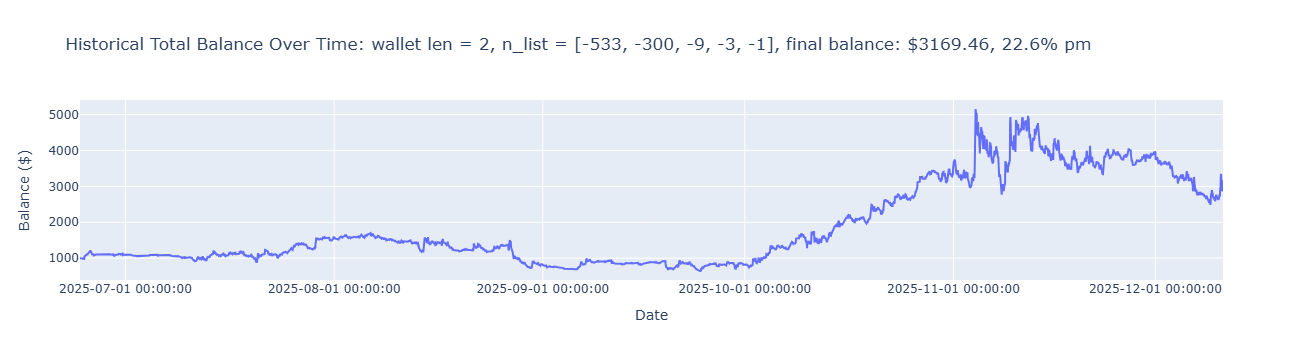

In [23]:
n_list = [-533, -300, -9, -3, -1]
plot_momentum(merged_backtests_df, pct_change_merged_backtests_df, n_list)

..........1000..........2000..........3000......... 3923
..........1000..........2000..........3000......... 3923
..........1000..........2000..........3000......... 3923
..........1000..........2000..........3000......... 3923
..........1000..........2000..........3000......... 3923
..........1000..........2000..........3000......... 3923
..........1000..........2000..........3000......... 3923
..........1000..........2000..........3000......... 3923
..........1000..........2000..........3000......... 3923
..........1000..........2000..........3000......... 3923

Wallet len = 10, final balance: $1192.59, 3.3% pm


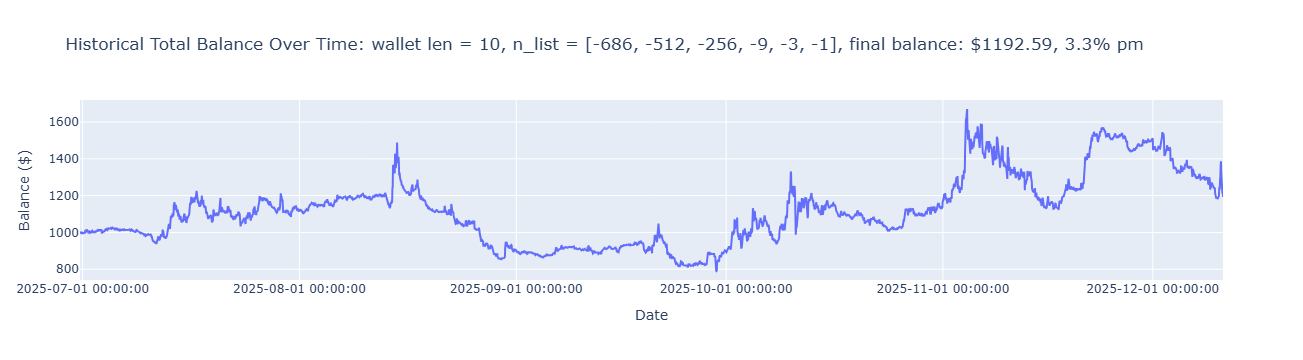

In [24]:
n_list = [-686, -512, -256, -9, -3, -1]
plot_momentum(merged_backtests_df, pct_change_merged_backtests_df, n_list)

..........1000..........2000..........3000..........4000
..........1000..........2000..........3000..........4000
..........1000..........2000..........3000..........4000
..........1000..........2000..........3000..........4000
..........1000..........2000..........3000..........4000
..........1000..........2000..........3000..........4000
..........1000..........2000..........3000..........4000
..........1000..........2000..........3000..........4000
..........1000..........2000..........3000..........4000
..........1000..........2000..........3000..........4000

Wallet len = 2, final balance: $3606.32, 26.0% pm


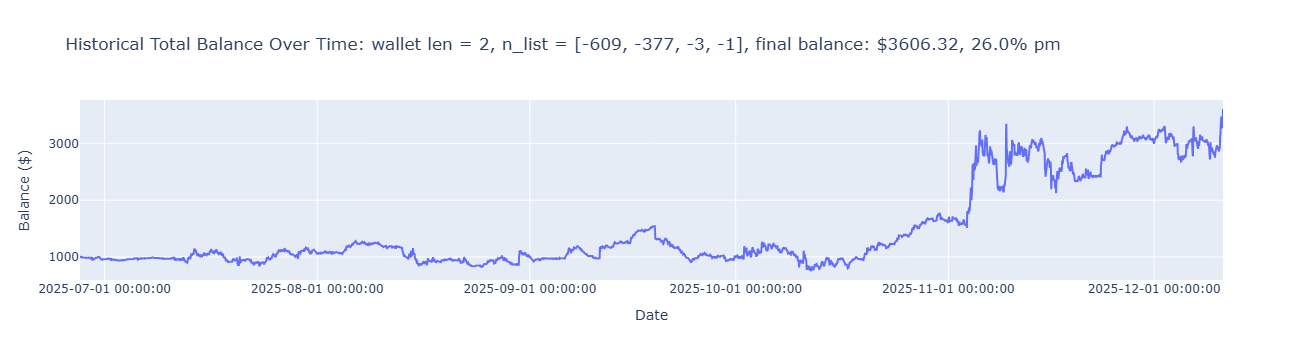

In [25]:
n_list = [-609, -377, -3, -1]
plot_momentum(merged_backtests_df, pct_change_merged_backtests_df, n_list)

..........1000..........2000..........3000..........4000...... 4608
..........1000..........2000..........3000..........4000...... 4608
..........1000..........2000..........3000..........4000...... 4608
..........1000..........2000..........3000..........4000...... 4608
..........1000..........2000..........3000..........4000...... 4608
..........1000..........2000..........3000..........4000...... 4608
..........1000..........2000..........3000..........4000...... 4608
..........1000..........2000..........3000..........4000...... 4608
..........1000..........2000..........3000..........4000...... 4608
..........1000..........2000..........3000..........4000...... 4608

Wallet len = 1, final balance: $2676.27, 16.6% pm


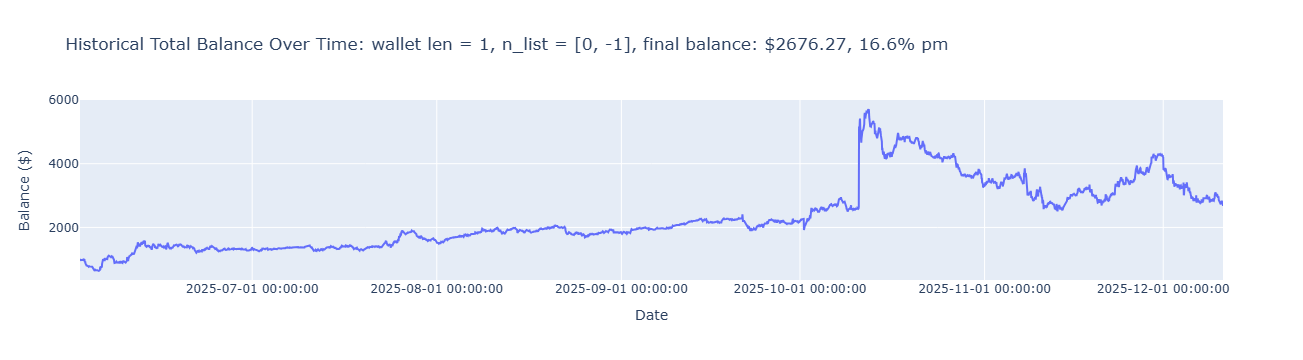

In [26]:
n_list = [0, -1]
plot_momentum(merged_backtests_df, pct_change_merged_backtests_df, n_list)

# Testes de desempenho individual de momentos

In [27]:
parado aí

SyntaxError: invalid syntax (3554115356.py, line 1)

In [28]:
balances = []

start = 2
end = 1000

for i in range(start, end):
    n_list = [-i, -1]
    history_date, history_balance, total_ballance, wallet, steps = manage_wallet(merged_backtests_df, pct_change_merged_backtests_df, n_list, 10, TOTAL_BALANCE, False, end)
    balances.append(total_ballance)
    print(f"i = {i}, {steps} steps, final balance: ${total_ballance:.2f}")

NameError: name 'manage_wallet' is not defined

In [ ]:
n_values = list(range(start, end))

In [ ]:
import os

# Combine n_values and balances into a DataFrame
new_balance_df = pd.DataFrame({'balance': balances}, index=n_values)

# Check if balance.csv already exists
if os.path.exists('balance.csv'):
    # Load the existing DataFrame
    existing_balance_df = pd.read_csv('balance.csv', index_col=0)

    # Append the new DataFrame to the existing one
    # Using concat to handle potential non-overlapping indices
    combined_balance_df = pd.concat([existing_balance_df, new_balance_df])

    # Remove duplicates in case of overlapping n_values and keep the last (newest) entry
    combined_balance_df = combined_balance_df[~combined_balance_df.index.duplicated(keep='last')]

    # Sort by index (n_values)
    combined_balance_df = combined_balance_df.sort_index()

    # Save the combined DataFrame to a CSV file
    combined_balance_df.to_csv('balance.csv')
    print("DataFrame updated and saved to balance.csv")
else:
    # Save the new DataFrame to a CSV file
    new_balance_df.to_csv('balance.csv')
    print("DataFrame saved to balance.csv")

In [ ]:
# # Load the balance.csv file
# balance_df = pd.read_csv('balance.csv', index_col=0)

# # Extract the index to n_values
# n_values = balance_df.index.tolist()

# # Extract the 'balance' column to balances
# balances = balance_df['balance'].tolist()

# print("n_values loaded:", n_values)
# print("balances loaded:", balances)

In [ ]:
# balance_sorted = balance_df.reset_index().sort_values(by='balance', ascending=False)
# balance_sorted.head(12)['index'].to_list()